# Energy Optimizer — Interactive Visualization

Runs the MILP HiGHS optimizer against `config.yaml` with live data from ioBroker.

**Four-step workflow — run cells in order:**

| Step | Cell | What it does |
|------|------|--------------|
| 1 | Configure | Set paths, cost basis, price tariff |
| 2 | Run optimizer | Fetch live data, build + solve MILP, print summary |
| 3 | Dispatch table | Per-step kW table for every battery |
| 4 | Diagram | Four-panel chart from the same optimizer result |

Steps 3 and 4 both read from the variables produced by Step 2, so table and diagram are always consistent with each other.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Resolve repo root -- VS Code sets __vsc_ipynb_file__ to the notebook path.
# Fall back to cwd if that variable is absent.
try:
    _nb_path = Path(globals().get('__vsc_ipynb_file__') or __file__).resolve()
except NameError:
    _nb_path = Path().resolve() / 'visualize_optimizer.ipynb'

_nb_dir   = _nb_path.parent
repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir

sys.path.insert(0, str(repo_root / 'src'))
sys.path.insert(0, str(repo_root / 'scripts'))

print(f'Repo root : {repo_root}')
print(f'Config    : {repo_root / "config.yaml"}')


Repo root : /Users/david/repos/energy-assistant
Config    : /Users/david/repos/energy-assistant/config.yaml


In [2]:
# ── Step 1: Configure ─────────────────────────────────────────────────────────

CONFIG_PATH  = repo_root / 'config.yaml'

# Set to a tariff ID (e.g. 'household') to pin the price source, or None to auto-detect.
PRICE_TARIFF = None

# Set to a file path string to also save a PNG, or None to skip saving.
SAVE_PATH    = None   # e.g. str(repo_root / 'optimizer_plan.png')

# ── Cost basis overrides ───────────────────────────────────────────────────────
# The price (€/kWh) at which energy CURRENTLY STORED was effectively "bought".
# Used as the minimum acceptable sell price (discharge threshold).
#
# None  → use the current spot price
# dict  → per-device override, e.g. PV-charged or cheap overnight energy
#
# Examples:
#   COST_BASIS = {"sma_battery": 0.12, "zendure": 0.08}  # charged cheap / from PV
#   COST_BASIS = {"sma_battery": 0.38}                    # override one device only
#   COST_BASIS = None                                      # always use spot price
COST_BASIS = {"sma_battery": 0.12, "zendure": 0.08}

# ── Terminal value overrides ───────────────────────────────────────────────────
# The expected FUTURE market value (€/kWh) of energy sitting in the batteries
# at the END of the planning horizon.  This controls PV recharge incentives:
#
#   The optimizer charges from PV only when:
#     terminal_value > export_price / η_c + degradation_cost
#                    ≈  0.082 / 0.95  + 0.059  =  0.145 €/kWh  (Zendure)
#                    ≈  0.082 / 0.95  + 0.079  =  0.165 €/kWh  (SMA)
#
# None  → auto-compute from forecast (70th-percentile of all horizon prices)
#         Typical result: ~0.35–0.40 €/kWh → PV charging enabled
# dict  → explicit per-device override
#
# Examples:
#   TERMINAL_VALUE = {"sma_battery": 0.30, "zendure": 0.25}  # explicit
#   TERMINAL_VALUE = None                                      # auto (recommended)
TERMINAL_VALUE = None


In [3]:
# ── Step 2: Run Optimizer ─────────────────────────────────────────────────────
# Fetches live prices, PV forecast, and battery SoC from ioBroker, then builds
# and solves the MILP.  All results are stored as kernel variables used by
# Steps 3 (table) and 4 (diagram).

import importlib, pulp
from datetime import datetime, timedelta, timezone
from energy_assistant.config.yaml import YamlConfigLoader
from energy_assistant.loader.device_loader import build as _build
from energy_assistant.core.models import (
    DeviceRole, DeviceState, ForecastPoint, ForecastQuantity, StorageConstraints,
)
from energy_assistant.core.optimizer import OptimizationContext
from energy_assistant.core.ledger import BatteryCostLedger
from energy_assistant.plugins._iobroker.pool import IoBrokerConnectionPool
from energy_assistant.core.plugin_registry import BuildContext

# Reload MILP modules first so code changes are picked up without a kernel restart.
# visualize_optimizer is reloaded after so it captures the updated optimizer class.
import energy_assistant.plugins.milp_highs.optimizer as _milp_mod
import energy_assistant.plugins.milp_highs as _milp_pkg
import visualize_optimizer as _vo
importlib.reload(_milp_mod)
importlib.reload(_milp_pkg)
importlib.reload(_vo)

from energy_assistant.plugins.milp_highs import MilpHigsOptimizer

# ── 1. Load config + build devices/tariffs ────────────────────────────────────
app_config = YamlConfigLoader(CONFIG_PATH).load()
device_registry, tariffs, _ = _build(app_config)

iobroker_pool = IoBrokerConnectionPool()
ctx = BuildContext(backends=app_config.backends, iobroker_pool=iobroker_pool, ha_client=None)
forecast_providers = _vo._build_forecast_providers(app_config, ctx)

# ── 2. Fetch with generous cap, then auto-detect actual horizon ───────────────
horizon_cap_h = int(app_config.optimizer.get("horizon_hours", 48))
horizon_cap   = timedelta(hours=horizon_cap_h)
now           = datetime.now(timezone.utc).replace(second=0, microsecond=0)

raw_prices, price_src = await _vo._fetch_raw_prices(tariffs, PRICE_TARIFF, horizon_cap)
raw_pv,    pv_src     = await _vo._fetch_raw_pv(forecast_providers, horizon_cap)

step_min  = _vo._detect_step_minutes(raw_prices, raw_pv)
step_td   = timedelta(minutes=step_min)
step_h    = step_min / 60.0

# Use the full extent of available data (capped at horizon_cap)
horizon   = _vo._infer_horizon(raw_prices, raw_pv, step_td, now, cap=horizon_cap)
horizon_h = int(horizon.total_seconds() / 3600)
timestamps = [now + step_td * i for i in range(int(horizon / step_td))]
prices    = _vo._align(raw_prices, timestamps)
pv_kw     = _vo._align(raw_pv, timestamps)

print(f"  Prices      : {price_src}")
print(f"  PV forecast : {pv_src}")
print(f"  Time step   : {step_min} min  →  {len(timestamps)} steps over {horizon_h} h")

# ── 3. Live SoC ───────────────────────────────────────────────────────────────
storage_devices = device_registry.by_role(DeviceRole.STORAGE)
storage_constraints: list[StorageConstraints] = []
device_states: dict[str, DeviceState] = {}

for dev in storage_devices:
    sc = getattr(dev, "storage_constraints", None)
    if sc is None:
        continue
    storage_constraints.append(sc)
    soc = await _vo._fetch_soc(dev)
    device_states[dev.device_id] = DeviceState(
        device_id=dev.device_id,
        soc_pct=soc if soc is not None else (sc.min_soc_pct + sc.max_soc_pct) / 2,
    )
    print(f"  SoC {dev.device_id:20s}: {device_states[dev.device_id].soc_pct:.1f} %")

# ── 4. Cost ledger ────────────────────────────────────────────────────────────
overrides    = COST_BASIS or {}
current_spot = prices[0] if prices else 0.25
ledger = BatteryCostLedger()
for sc in storage_constraints:
    stored = sc.capacity_kwh * (device_states[sc.device_id].soc_pct or 0) / 100
    basis  = overrides.get(sc.device_id, current_spot)
    ledger.initialise(sc.device_id, stored, basis)

baseline_kw = float(app_config.optimizer.get("baseline_load_kw", 0.0))

# ── 5. Terminal value basis ───────────────────────────────────────────────────
# Reflects the EXPECTED FUTURE VALUE of stored energy at horizon end.
# Must exceed (export_price / η_c + degradation) for PV charging to be triggered.
# export_price ≈ 0.082, η_c ≈ 0.95 → threshold ≈ 0.145 €/kWh (Zendure/SMA).
if TERMINAL_VALUE is not None:
    terminal_value_basis = {sc.device_id: TERMINAL_VALUE.get(sc.device_id, current_spot)
                             for sc in storage_constraints}
else:
    # Auto: 70th percentile of all forecast prices.  This captures the typical
    # evening peak value, comfortably above the ~0.145 PV-charging threshold.
    p70 = sorted(prices)[int(0.70 * len(prices))]
    terminal_value_basis = {sc.device_id: p70 for sc in storage_constraints}

# ── 6. Battery overview ───────────────────────────────────────────────────────
print()
print(f"  {'Device':<22}  {'Capacity':>9}  {'CostBasis':>9}  {'Wear €/kWh':>10}  {'TV €/kWh':>9}")
print("  " + "─" * 68)
for sc in storage_constraints:
    basis = ledger.all_cost_bases().get(sc.device_id, current_spot)
    tv    = terminal_value_basis[sc.device_id]
    pv_threshold = 0.082 / sc.charge_efficiency + sc.degradation_cost_per_kwh
    pv_flag = "✓ PV charges" if tv > pv_threshold else "✗ no PV chg"
    print(f"  {sc.device_id:<22}  {sc.capacity_kwh:>7.1f} kWh"
          f"  {basis:>7.4f} €    {sc.degradation_cost_per_kwh:>8.4f} €    {tv:>7.4f} €  {pv_flag}")

# ── 7. Build OptimizationContext ──────────────────────────────────────────────
context = OptimizationContext(
    device_states=device_states,
    storage_constraints=storage_constraints,
    tariffs=tariffs,
    forecasts={
        ForecastQuantity.PRICE:         [ForecastPoint(timestamp=ts, value=p) for ts, p in zip(timestamps, prices)],
        ForecastQuantity.PV_GENERATION: [ForecastPoint(timestamp=ts, value=v) for ts, v in zip(timestamps, pv_kw)],
        ForecastQuantity.CONSUMPTION:   [ForecastPoint(timestamp=ts, value=baseline_kw) for ts in timestamps],
    },
    horizon=horizon,
    battery_cost_basis=ledger.all_cost_bases(),
)

# ── 8. Build + solve MILP ─────────────────────────────────────────────────────
optimizer     = MilpHigsOptimizer(step_minutes=step_min)
export_prices = await optimizer._resolve_export_prices(context, timestamps)
net_load      = [(baseline_kw - pv) * step_h for pv in pv_kw]
initial_energy = {
    sc.device_id: sc.capacity_kwh * (device_states[sc.device_id].soc_pct or 0) / 100
    for sc in storage_constraints
}

prob, variables = optimizer._build_model(
    len(timestamps), step_h, storage_constraints, net_load,
    prices, export_prices, initial_energy, context.battery_cost_basis,
    terminal_value_basis,
)
status = prob.solve(optimizer._get_solver())
print(f"\n  Solver: {pulp.LpStatus[status]}  — Steps 3 and 4 are ready.")


  Prices      : live — tariff 'household'
  PV forecast : live — PvForecastIoBrokerForecast
  Time step   : 15 min  →  121 steps over 30 h
  SoC sma_battery         : 97.0 %
  SoC zendure             : 98.0 %

  Device                   Capacity  CostBasis  Wear €/kWh   TV €/kWh
  ────────────────────────────────────────────────────────────────────
  sma_battery                 7.4 kWh   0.1200 €      0.0788 €     0.3761 €  ✓ PV charges
  zendure                     7.6 kWh   0.0800 €      0.0592 €     0.3761 €  ✓ PV charges

  Solver: Optimal  — Steps 3 and 4 are ready.


In [4]:
# ── Step 2: Run Optimizer ─────────────────────────────────────────────────────
# Fetches live prices, PV forecast, and battery SoC from ioBroker, then builds
# and solves the MILP.  All results are stored as kernel variables used by
# Steps 3 (table) and 4 (diagram).

import importlib, pulp
from datetime import datetime, timedelta, timezone
from energy_assistant.config.yaml import YamlConfigLoader
from energy_assistant.loader.device_loader import build as _build, build_device_forecasts
from energy_assistant.core.models import (
    DeviceRole, DeviceState, ForecastPoint, ForecastQuantity, StorageConstraints,
)
from energy_assistant.core.optimizer import OptimizationContext
from energy_assistant.core.ledger import BatteryCostLedger
from energy_assistant.plugins._iobroker.pool import IoBrokerConnectionPool
from energy_assistant.core.plugin_registry import BuildContext

# Reload MILP modules first so code changes are picked up without a kernel restart.
# visualize_optimizer is reloaded after so it captures the updated optimizer class.
import energy_assistant.plugins.milp_highs.optimizer as _milp_mod
import energy_assistant.plugins.milp_highs as _milp_pkg
import visualize_optimizer as _vo
importlib.reload(_milp_mod)
importlib.reload(_milp_pkg)
importlib.reload(_vo)

from energy_assistant.plugins.milp_highs import MilpHigsOptimizer

# ── 1. Load config + build devices/tariffs ────────────────────────────────────
app_config = YamlConfigLoader(CONFIG_PATH).load()
device_registry, tariffs, _ = _build(app_config)

iobroker_pool = IoBrokerConnectionPool()
ctx = BuildContext(backends=app_config.backends, iobroker_pool=iobroker_pool, ha_client=None)
forecast_providers = _vo._build_forecast_providers(app_config, ctx)
device_forecasts   = build_device_forecasts(app_config, ctx)

# ── 2. Fetch with generous cap, then auto-detect actual horizon ───────────────
horizon_cap_h = int(app_config.optimizer.get("horizon_hours", 48))
horizon_cap   = timedelta(hours=horizon_cap_h)
now           = datetime.now(timezone.utc).replace(second=0, microsecond=0)

raw_prices, price_src = await _vo._fetch_raw_prices(tariffs, PRICE_TARIFF, horizon_cap)
raw_pv,    pv_src     = await _vo._fetch_raw_pv(forecast_providers, horizon_cap)

step_min  = _vo._detect_step_minutes(raw_prices, raw_pv)
step_td   = timedelta(minutes=step_min)
step_h    = step_min / 60.0

# Use the full extent of available data (capped at horizon_cap)
horizon   = _vo._infer_horizon(raw_prices, raw_pv, step_td, now, cap=horizon_cap)
horizon_h = int(horizon.total_seconds() / 3600)
timestamps = [now + step_td * i for i in range(int(horizon / step_td))]
prices    = _vo._align(raw_prices, timestamps)
pv_kw     = _vo._align(raw_pv, timestamps)

print(f"  Prices      : {price_src}")
print(f"  PV forecast : {pv_src}")
print(f"  Time step   : {step_min} min  →  {len(timestamps)} steps over {horizon_h} h")

# ── 3. Consumption forecast (summed from device static_profile forecasts) ─────
consumption_fc, consumption_src = await _vo._fetch_raw_consumption(
    device_forecasts, timestamps, horizon
)
consumption_kw = [fp.value for fp in consumption_fc]
print(f"  Consumption : {consumption_src}")

# ── 4. Live SoC ───────────────────────────────────────────────────────────────
storage_devices = device_registry.by_role(DeviceRole.STORAGE)
storage_constraints: list[StorageConstraints] = []
device_states: dict[str, DeviceState] = {}

for dev in storage_devices:
    sc = getattr(dev, "storage_constraints", None)
    if sc is None:
        continue
    storage_constraints.append(sc)
    soc = await _vo._fetch_soc(dev)
    device_states[dev.device_id] = DeviceState(
        device_id=dev.device_id,
        soc_pct=soc if soc is not None else (sc.min_soc_pct + sc.max_soc_pct) / 2,
    )
    print(f"  SoC {dev.device_id:20s}: {device_states[dev.device_id].soc_pct:.1f} %")

# ── 5. Cost ledger ────────────────────────────────────────────────────────────
overrides    = COST_BASIS or {}
current_spot = prices[0] if prices else 0.25
ledger = BatteryCostLedger()
for sc in storage_constraints:
    stored = sc.capacity_kwh * (device_states[sc.device_id].soc_pct or 0) / 100
    basis  = overrides.get(sc.device_id, current_spot)
    ledger.initialise(sc.device_id, stored, basis)

# ── 6. Terminal value basis ───────────────────────────────────────────────────
if TERMINAL_VALUE is not None:
    terminal_value_basis = {sc.device_id: TERMINAL_VALUE.get(sc.device_id, current_spot)
                             for sc in storage_constraints}
else:
    p70 = sorted(prices)[int(0.70 * len(prices))]
    terminal_value_basis = {sc.device_id: p70 for sc in storage_constraints}

# ── 7. Battery overview ───────────────────────────────────────────────────────
print()
print(f"  {'Device':<22}  {'Capacity':>9}  {'CostBasis':>9}  {'Wear €/kWh':>10}  {'TV €/kWh':>9}")
print("  " + "─" * 68)
for sc in storage_constraints:
    basis = ledger.all_cost_bases().get(sc.device_id, current_spot)
    tv    = terminal_value_basis[sc.device_id]
    pv_threshold = 0.082 / sc.charge_efficiency + sc.degradation_cost_per_kwh
    pv_flag = "✓ PV charges" if tv > pv_threshold else "✗ no PV chg"
    print(f"  {sc.device_id:<22}  {sc.capacity_kwh:>7.1f} kWh"
          f"  {basis:>7.4f} €    {sc.degradation_cost_per_kwh:>8.4f} €    {tv:>7.4f} €  {pv_flag}")

# ── 8. Build OptimizationContext ──────────────────────────────────────────────
context = OptimizationContext(
    device_states=device_states,
    storage_constraints=storage_constraints,
    tariffs=tariffs,
    forecasts={
        ForecastQuantity.PRICE:         [ForecastPoint(timestamp=ts, value=p) for ts, p in zip(timestamps, prices)],
        ForecastQuantity.PV_GENERATION: [ForecastPoint(timestamp=ts, value=v) for ts, v in zip(timestamps, pv_kw)],
        ForecastQuantity.CONSUMPTION:   consumption_fc,
    },
    horizon=horizon,
    battery_cost_basis=ledger.all_cost_bases(),
)

# ── 9. Build + solve MILP ─────────────────────────────────────────────────────
optimizer     = MilpHigsOptimizer(step_minutes=step_min)
export_prices = await optimizer._resolve_export_prices(context, timestamps)
net_load      = [(c - pv) * step_h for c, pv in zip(consumption_kw, pv_kw)]
initial_energy = {
    sc.device_id: sc.capacity_kwh * (device_states[sc.device_id].soc_pct or 0) / 100
    for sc in storage_constraints
}

prob, variables = optimizer._build_model(
    len(timestamps), step_h, storage_constraints, net_load,
    prices, export_prices, initial_energy, context.battery_cost_basis,
    terminal_value_basis,
)
status = prob.solve(optimizer._get_solver())
print(f"\n  Solver: {pulp.LpStatus[status]}  — Steps 3 and 4 are ready.")


  Prices      : live — tariff 'household'
  PV forecast : live — PvForecastIoBrokerForecast
  Time step   : 15 min  →  121 steps over 30 h
  Consumption : StaticProfileForecast, StaticProfileForecast, StaticProfileForecast, StaticProfileForecast
  SoC sma_battery         : 97.0 %
  SoC zendure             : 98.0 %

  Device                   Capacity  CostBasis  Wear €/kWh   TV €/kWh
  ────────────────────────────────────────────────────────────────────
  sma_battery                 7.4 kWh   0.1200 €      0.0788 €     0.3761 €  ✓ PV charges
  zendure                     7.6 kWh   0.0800 €      0.0592 €     0.3761 €  ✓ PV charges

  Solver: Optimal  — Steps 3 and 4 are ready.


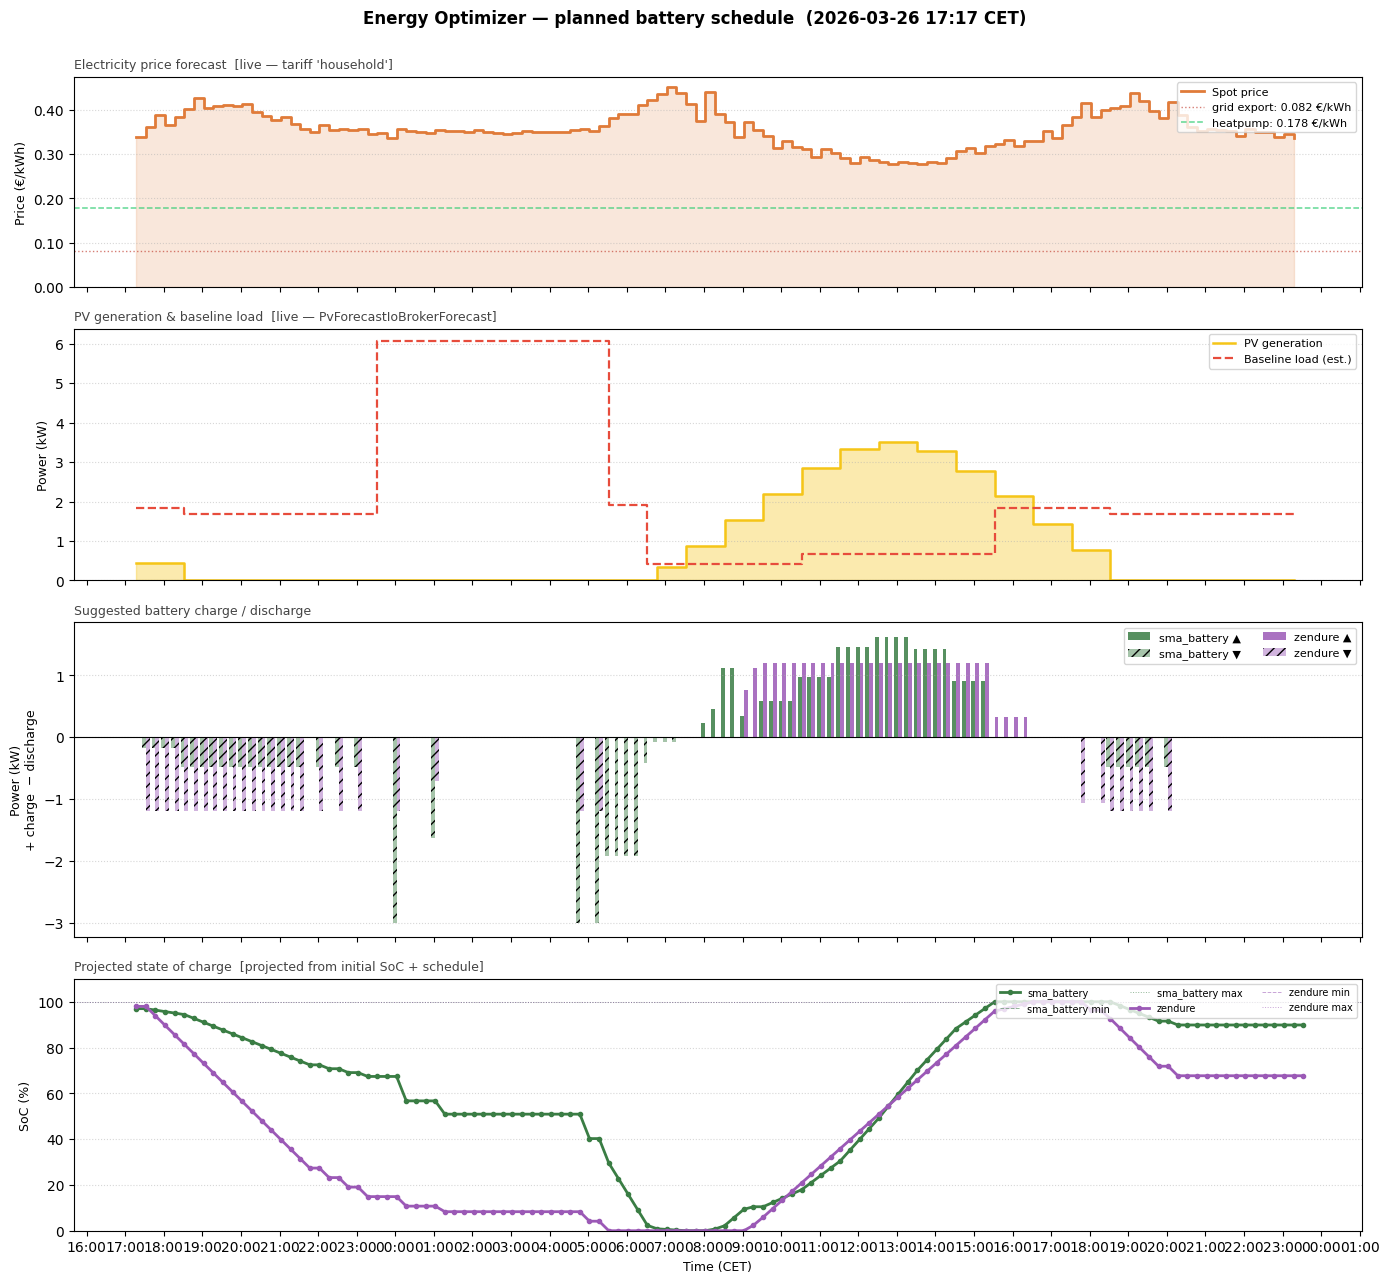

In [5]:
# ── Step 4: Diagram ───────────────────────────────────────────────────────────
# Renders the four-panel chart from the same LP variables as Step 3.
# The LP solution is converted to an EnergyPlan (same path as the real optimizer),
# then passed to the standard plot function.

from energy_assistant.core.models import EnergyPlan
from energy_assistant.plugins.milp_highs.optimizer import _extract_intents

intents = _extract_intents(storage_constraints, variables, timestamps, step_h)
plan    = EnergyPlan(horizon_hours=int(horizon.total_seconds() / 3600), intents=intents)
series  = _vo._extract_series(context, plan, timestamps, step_min)
_vo._plot(context, plan, series, price_src, pv_src, SAVE_PATH,
          tariffs=tariffs, step_min=step_min)


  Baseline cost :  +19.843 €
  Optimised cost:  +14.584 €
  Net saving    :  +5.258 €  (+26.5 %)


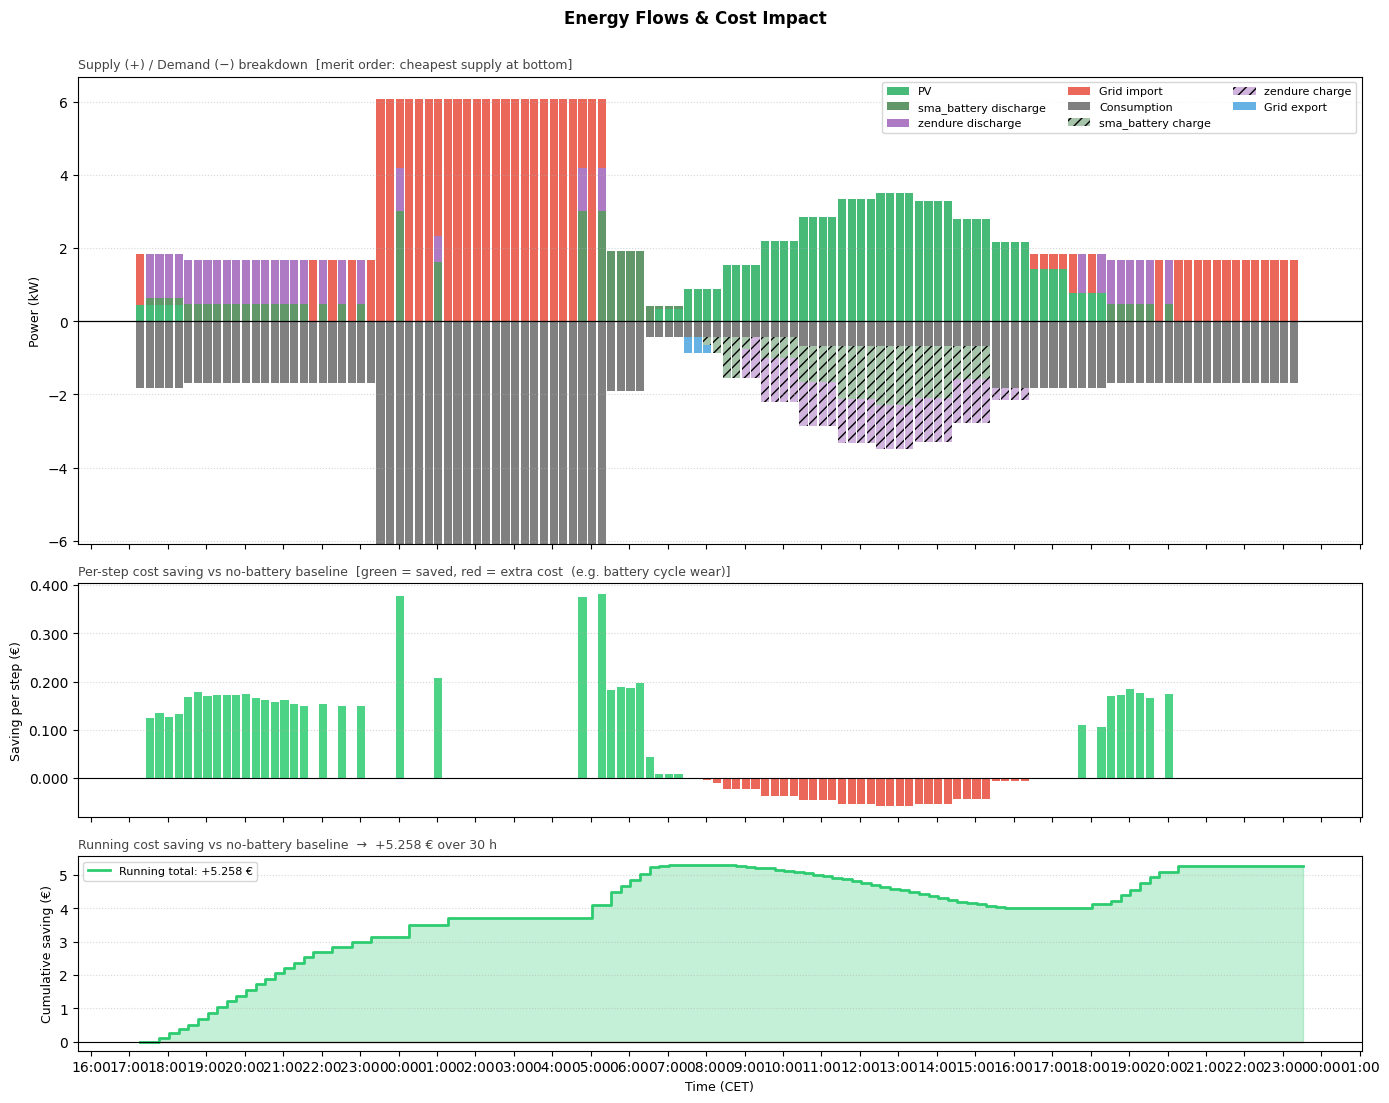

In [6]:
# ── Step 5: Energy Flows & Cost Impact ───────────────────────────────────────
# Three-panel chart built directly from the LP solution in the kernel:
#   Panel 1 — Supply/demand breakdown: who generates, who consumes, every step.
#   Panel 2 — Per-step saving vs the no-battery baseline (green = saved, red = extra).
#   Panel 3 — Running total saving over the full horizon.
#
# Requires Step 2 to have been run first.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

_PALETTE = _vo._PALETTE
N = len(timestamps)
T = range(N)

# ── 1. Extract LP solution values ─────────────────────────────────────────────
g_imp_kwh     = [pulp.value(variables["g_imp"][t]) or 0.0 for t in T]
g_exp_kwh     = [pulp.value(variables["g_exp"][t]) or 0.0 for t in T]
charge_kwh    = {sc.device_id: [pulp.value(variables["c"][(sc.device_id, t)]) or 0.0 for t in T]
                 for sc in storage_constraints}
discharge_kwh = {sc.device_id: [pulp.value(variables["d"][(sc.device_id, t)]) or 0.0 for t in T]
                 for sc in storage_constraints}

# kWh/step → kW
g_imp_kw     = [v / step_h for v in g_imp_kwh]
g_exp_kw     = [v / step_h for v in g_exp_kwh]
charge_kw    = {bid: [v / step_h for v in vals] for bid, vals in charge_kwh.items()}
discharge_kw = {bid: [v / step_h for v in vals] for bid, vals in discharge_kwh.items()}

# ── 2. Cost comparison ─────────────────────────────────────────────────────────
# Optimised: exactly what the LP paid for its import/export decisions
opt_cost = [prices[t] * g_imp_kwh[t] - export_prices[t] * g_exp_kwh[t] for t in T]

# No-battery baseline: PV covers load first; surplus/deficit from/to grid
baseline_cost = [
    max(0.0, consumption_kw[t] - pv_kw[t]) * step_h * prices[t]
    - max(0.0, pv_kw[t] - consumption_kw[t]) * step_h * export_prices[t]
    for t in T
]

saving_per_step = [b - o for b, o in zip(baseline_cost, opt_cost)]
cum_saving      = list(np.cumsum(saving_per_step))
total_opt       = sum(opt_cost)
total_base      = sum(baseline_cost)
total_save      = sum(saving_per_step)

print(f"  Baseline cost :  {total_base:+.3f} €")
print(f"  Optimised cost:  {total_opt:+.3f} €")
if total_base:
    print(f"  Net saving    :  {total_save:+.3f} €  ({total_save / total_base * 100:+.1f} %)")

# ── 3. Plot ────────────────────────────────────────────────────────────────────
local_tz = datetime.now().astimezone().tzinfo
xs    = timestamps
bar_w = timedelta(minutes=step_min * 0.85)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True,
                          gridspec_kw={"height_ratios": [2.4, 1.2, 1.0]})
fig.suptitle("Energy Flows & Cost Impact", fontsize=12, fontweight="bold", y=0.999)

# ── Panel 1: Supply (+) / Demand (−) ─────────────────────────────────────────
ax = axes[0]

# Supply layers (stacked above zero, merit order: cheapest at bottom)
supply_layers = [("PV", "#27ae60", pv_kw, {"alpha": 0.85})]
for i, sc in enumerate(storage_constraints):
    supply_layers.append((f"{sc.device_id} discharge",
                           _PALETTE[i % len(_PALETTE)],
                           discharge_kw[sc.device_id], {"alpha": 0.80}))
supply_layers.append(("Grid import", "#e74c3c", g_imp_kw, {"alpha": 0.85}))

bottom = np.zeros(N)
for label, color, data, kw in supply_layers:
    arr = np.array(data)
    ax.bar(xs, arr, bottom=bottom, width=bar_w, color=color,
           label=label, align="center", **kw)
    bottom += arr

# Demand layers (stacked below zero)
demand_layers = [("Consumption", "#555555", consumption_kw, {"alpha": 0.75})]
for i, sc in enumerate(storage_constraints):
    demand_layers.append((f"{sc.device_id} charge",
                           _PALETTE[i % len(_PALETTE)],
                           charge_kw[sc.device_id], {"alpha": 0.45, "hatch": "///"}))
demand_layers.append(("Grid export", "#3498db", g_exp_kw, {"alpha": 0.75}))

bottom = np.zeros(N)
for label, color, data, kw in demand_layers:
    arr = np.array(data)
    ax.bar(xs, -arr, bottom=-bottom, width=bar_w, color=color,
           label=label, align="center", **kw)
    bottom += arr

ax.axhline(0, color="black", linewidth=0.9)
ax.set_ylabel("Power (kW)", fontsize=9)
ax.set_title("Supply (+) / Demand (−) breakdown  [merit order: cheapest supply at bottom]",
             fontsize=9, loc="left", color="#444")
ax.legend(fontsize=8, loc="upper right", ncol=3)
ax.grid(axis="y", linestyle=":", alpha=0.5)

# ── Panel 2: Per-step saving ──────────────────────────────────────────────────
ax = axes[1]
save_arr = np.array(saving_per_step)
colors   = ["#2ecc71" if v >= 0 else "#e74c3c" for v in save_arr]
ax.bar(xs, save_arr, width=bar_w, color=colors, alpha=0.85, align="center")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Saving per step (€)", fontsize=9)
ax.set_title("Per-step cost saving vs no-battery baseline  "
             "[green = saved, red = extra cost  (e.g. battery cycle wear)]",
             fontsize=9, loc="left", color="#444")
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

# ── Panel 3: Cumulative saving ────────────────────────────────────────────────
ax = axes[2]
xs_ext  = xs + [xs[-1] + timedelta(minutes=step_min)]
cum_ext = [0.0] + cum_saving
pos_cum = [max(0.0, v) for v in cum_ext]
neg_cum = [min(0.0, v) for v in cum_ext]
line_color = "#2ecc71" if total_save >= 0 else "#e74c3c"
ax.fill_between(xs_ext, pos_cum, step="post", color="#2ecc71", alpha=0.28)
ax.fill_between(xs_ext, neg_cum, step="post", color="#e74c3c", alpha=0.28)
ax.step(xs_ext, cum_ext, where="post", color=line_color, linewidth=2,
        label=f"Running total: {total_save:+.3f} €")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Cumulative saving (€)", fontsize=9)
ax.set_title(f"Running cost saving vs no-battery baseline  →  {total_save:+.3f} € over {horizon_h} h",
             fontsize=9, loc="left", color="#444")
ax.legend(fontsize=8, loc="upper left")
ax.grid(axis="y", linestyle=":", alpha=0.5)

# ── Shared X-axis ──────────────────────────────────────────────────────────────
tick_h = 1 if step_min <= 30 else 2
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=tick_h))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=local_tz))
axes[-1].set_xlabel(f"Time ({local_tz})", fontsize=9)
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, ha="center")

fig.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()
